<a href="https://colab.research.google.com/github/nurqalbuam-design/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas_Praktikum_Minggu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [ ]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1021)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 + 21
beta0 = 10 + 21
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


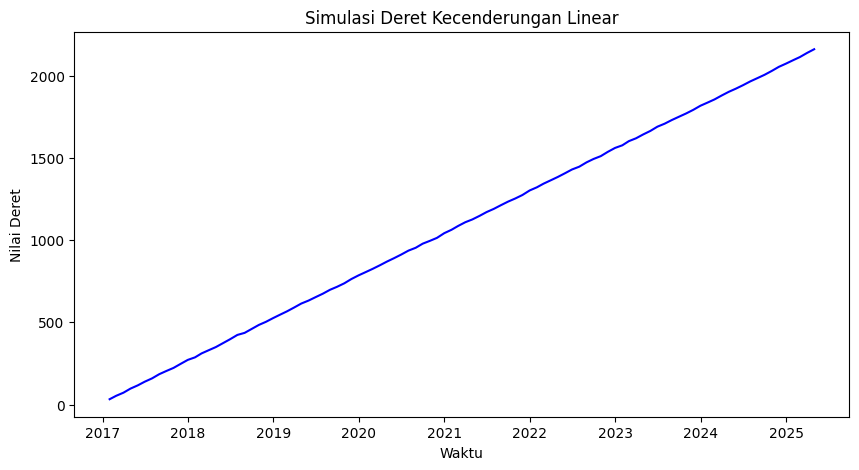

In [ ]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

Berdasarkan plot deret waktu, terlihat bahwa nilai deret mengalami peningkatan secara konsisten seiring bertambahnya waktu. Pola peningkatan tersebut membentuk garis yang hampir lurus dengan kemiringan positif, sehingga menunjukkan adanya kecenderungan (tren) linear positif. Fluktuasi acak pada data relatif kecil dibandingkan dengan besarnya tren, sehingga pola linear terlihat sangat jelas. Dengan demikian, semakin bertambah waktu, nilai deret cenderung meningkat dengan laju yang relatif konstan.

Berdasarkan hasil perhitungan, diperoleh nilai korelasi antara waktu (Time_Numeric) dan nilai deret (Value) sebesar 1.0000. Nilai tersebut menunjukkan adanya hubungan linear positif yang sangat kuat antara waktu dan nilai deret. Artinya, semakin bertambah waktu, nilai deret juga semakin meningkat. Hasil ini sesuai dengan plot deret waktu yang menunjukkan pola kecenderungan linear positif yang sangat kuat.

In [ ]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [ ]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.958e+06
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          3.67e-247
Time:                        07:22:51   Log-Likelihood:                -208.51
No. Observations:                 100   AIC:                             421.0
Df Residuals:                      98   BIC:                             426.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           31.1312      0.390     79.747   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

**Jawab**

Berdasarkan data simulasi, parameter asli yang digunakan adalah $\beta_0$ =31 dan $\beta_1$=21.5. Sementara itu, hasil estimasi model regresi menghasilkan nilai intercept sebesar 31.1312 dan koefisien Time_Numeric sebesar 21.4982. Dengan demikian, model regresi yang diperoleh adalah:

$$ \hat{Y}_t = 31.1312 + 21.4982t $$

Nilai parameter hasil estimasi sangat dekat dengan parameter asli yang digunakan dalam pembangkitan data. Intercept hasil estimasi sebesar 31.1312 mendekati nilai asli 31, sedangkan koefisien waktu sebesar 21.4982 juga sangat dekat dengan nilai asli 21.5. Hal ini menunjukkan bahwa model regresi mampu mengestimasi parameter sebenarnya dengan sangat baik.

Apakah model regresi yang dipaskan sudah bagus?

**Jawab**

Ya, model regresi yang dipaskan sudah sangat baik. Hal ini ditunjukkan oleh nilai \(R^2=1.000\), yang berarti hampir seluruh variasi nilai deret dapat dijelaskan oleh variabel waktu. Selain itu, koefisien Time_Numeric memiliki p-value 0.000 (<0.05) sehingga waktu berpengaruh signifikan terhadap nilai deret. Nilai koefisien hasil estimasi juga sangat dekat dengan parameter asli yang digunakan dalam simulasi. Dengan demikian, model regresi linear sangat baik dalam menggambarkan kecenderungan linear pada deret tersebut.


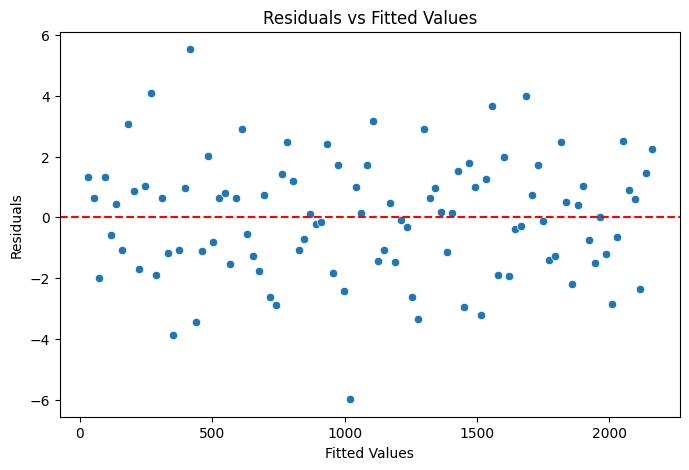

In [ ]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

**Jawab**

Berdasarkan plot Residuals vs Fitted Values, residual terlihat menyebar secara acak di sekitar garis nol dan tidak membentuk pola tertentu. Tidak terlihat pola melengkung maupun pola mengerucut atau melebar secara sistematis. Hal ini menunjukkan bahwa secara visual hubungan linear yang digunakan dalam model sudah sesuai dan varians residual relatif konstan. Dengan demikian, plot tersebut tidak menunjukkan adanya indikasi kuat pelanggaran asumsi linearitas maupun homoskedastisitas.


In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.4977


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

**Jawab**

Berdasarkan hasil uji Breusch-Pagan diperoleh p-value sebesar 0.4977. Karena p-value sebesar 0.4977 > 0.05, maka gagal menolak H0. Dengan demikian, tidak terdapat bukti adanya heteroskedastisitas, sehingga asumsi homoskedastisitas pada model regresi terpenuhi.


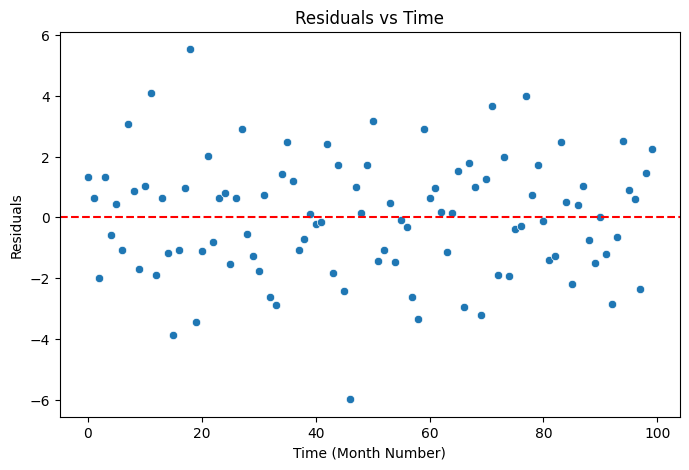

In [ ]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


**Interpretasi**

Berdasarkan plot Residuals vs Time, residual terlihat berfluktuasi di sekitar nilai nol sepanjang waktu dan tidak menunjukkan pola tren naik, tren turun, maupun pola sistematis yang jelas. Hal ini menunjukkan bahwa secara visual residual relatif acak terhadap waktu dan tidak terdapat kecenderungan tertentu yang belum ditangkap oleh model. Dengan demikian, model regresi linear telah cukup baik dalam menangkap pola utama pada deret waktu.

<Figure size 800x500 with 0 Axes>

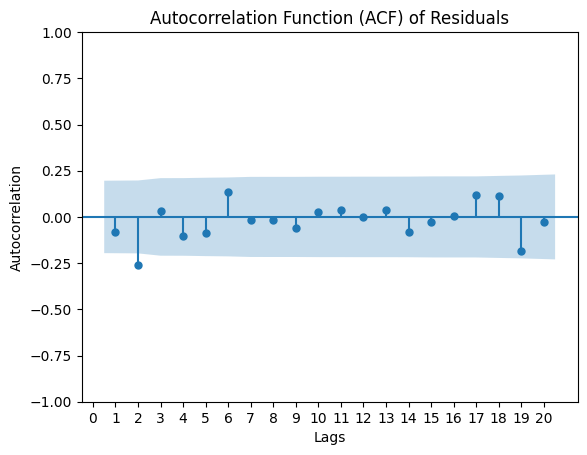

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

**Jawab**

Berdasarkan plot ACF residual, sebagian besar nilai autokorelasi pada berbagai lag berada di dalam batas interval kepercayaan. Hal ini menunjukkan bahwa secara umum tidak terdapat autokorelasi residual yang kuat.

Namun, terdapat nilai autokorelasi pada lag tertentu yang tampak melewati atau mendekati batas interval kepercayaan. Oleh karena itu, kesimpulan mengenai independensi residual perlu dikonfirmasi lebih lanjut menggunakan uji Ljung-Box.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.665135   0.414753
2    7.619573   0.022153
3    7.738076   0.051747
4    8.924486   0.063015
5    9.769833   0.082026
6   11.758260   0.067584
7   11.787270   0.107775
8   11.816075   0.159601
9   12.209714   0.201743
10  12.293533   0.265892
11  12.447831   0.330939
12  12.448185   0.410389
13  12.626937   0.477023
14  13.384348   0.496508
15  13.487664   0.564686
16  13.491258   0.636556
17  15.283039   0.575103
18  16.953833   0.526281
19  21.153934   0.328358


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

**Jawab**

Berdasarkan hasil uji Ljung-Box, pada lag ke-2 diperoleh *p-value* sebesar 0.022 yang lebih kecil dari taraf signifikansi $\alpha = 0.05$. Oleh karena itu, $H_0$ ditolak pada lag ke-2, sehingga terdapat indikasi autokorelasi residual sampai lag ke-2.

Namun, pada sebagian besar lag lainnya diperoleh *p-value* yang lebih besar dari 0.05. Dengan demikian, terdapat indikasi autokorelasi pada lag ke-2, tetapi tidak terdapat bukti autokorelasi yang signifikan secara konsisten pada lag-lag berikutnya.

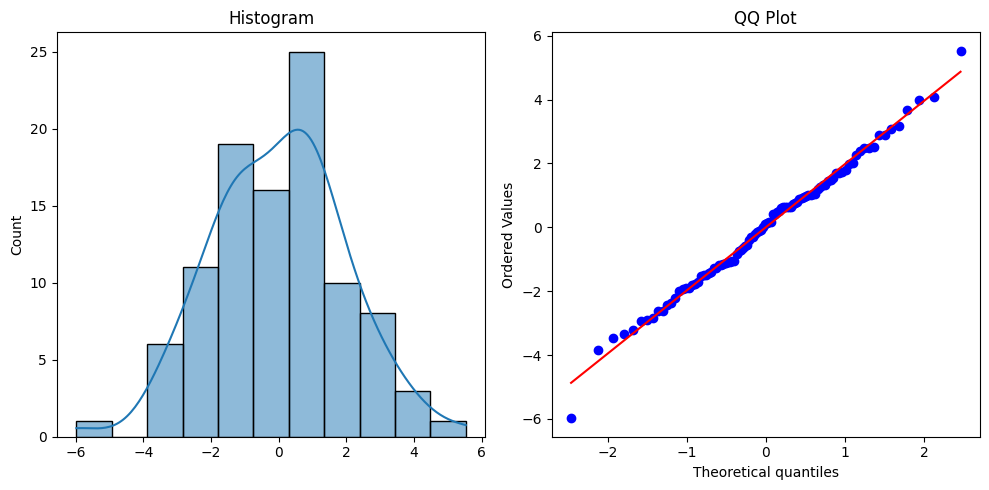

In [ ]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

**Jawab**

Berdasarkan histogram, residual terlihat relatif simetris dan membentuk pola yang mendekati distribusi normal. Pada QQ Plot, sebagian besar titik residual berada di sekitar garis diagonal, meskipun terdapat sedikit penyimpangan pada bagian ekor.

Dengan demikian, secara visual residual dapat dikatakan mendekati distribusi normal.

In [ ]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9948946764274994, p-value = 0.9723457895922107


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

**Jawab**

Berdasarkan hasil uji Shapiro-Wilk, diperoleh nilai statistik uji sebesar 0.9949 dan *p-value* sebesar 0.9723.

Hipotesis yang digunakan adalah:

$H_0$: residual berdistribusi normal.

$H_1$: residual tidak berdistribusi normal.

Karena *p-value* = 0.9723 > $\alpha = 0.05$, maka gagal menolak $H_0$. Dengan demikian, tidak terdapat cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal, sehingga asumsi normalitas residual dapat dianggap terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [ ]:
# Menentukan parameter simulasi
np.random.seed(1021)
n_periods = 120
beta_0, beta_1, beta_2= 71, 21.5, 21.02
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

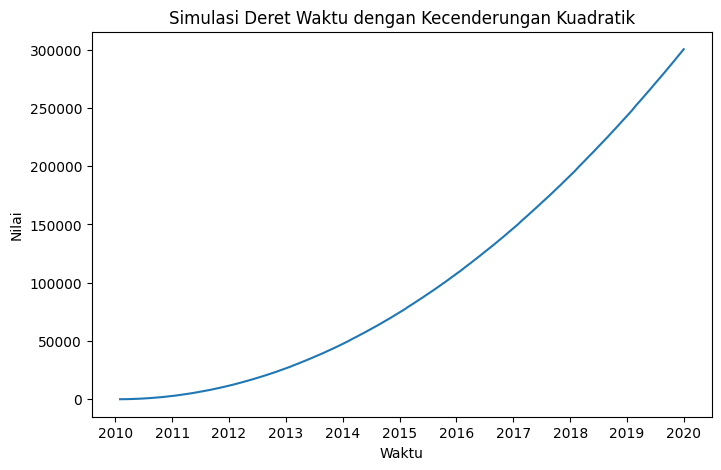

In [ ]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

**Jawab**

Berdasarkan plot deret waktu, terlihat bahwa nilai deret mengalami peningkatan seiring bertambahnya waktu dengan laju peningkatan yang semakin besar. Pola tersebut membentuk kurva yang melengkung ke atas, sehingga menunjukkan adanya kecenderungan kuadratik positif.

Dari plot terlihat bahwa nilai deret terus meningkat dari waktu ke waktu, tetapi kenaikannya tidak membentuk garis lurus. Semakin bertambah waktu, kenaikan nilainya juga semakin cepat sehingga grafik terlihat melengkung ke atas.

Berbeda dengan pola kecenderungan linear yang naik dengan laju relatif tetap, pada kecenderungan kuadratik laju kenaikannya berubah dan menjadi semakin besar seiring waktu. Jadi, pola linear cenderung membentuk garis lurus, sedangkan pola kuadratik membentuk kurva.

In [ ]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.280e+09
Date:                Thu, 03 Sep 2026   Prob (F-statistic):               0.00
Time:                        07:22:59   Log-Likelihood:                -440.44
No. Observations:                 120   AIC:                             886.9
Df Residuals:                     117   BIC:                             895.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         72.2732      2.592     27.886      0.0

**Jawab**


Berdasarkan hasil regresi, diperoleh model:

$$
\hat{Y}_t = 72.2732 + 21.4709t + 21.0200t^2
$$

Nilai konstanta sebesar 72.2732 merupakan nilai dugaan $Y$ ketika $t=0$. Koefisien $t$ sebesar 21.4709 menunjukkan adanya kecenderungan linear positif, sedangkan koefisien $t^2$ sebesar 21.0200 menunjukkan adanya pola kuadratik positif. Artinya, nilai deret tidak hanya meningkat dari waktu ke waktu, tetapi kenaikannya juga menjadi semakin cepat.

Nilai $R^2$ dan Adjusted $R^2$ sebesar 1.000 menunjukkan bahwa model kuadratik mampu menjelaskan hampir seluruh variasi pada data.

Nilai Prob(F-statistic) = 0.00 < 0.05 menunjukkan bahwa model secara keseluruhan signifikan. Selain itu, $t$ dan $t^2$ masing-masing memiliki *p-value* sebesar 0.000 < 0.05, sehingga kedua komponen tersebut signifikan dalam menjelaskan nilai deret.

Nilai Durbin-Watson = 2.168 yang mendekati 2 menunjukkan bahwa secara awal tidak terlihat adanya autokorelasi residual yang kuat.

Nilai Prob(Omnibus) = 0.767 dan Prob(Jarque-Bera) = 0.910 lebih besar dari 0.05. Hal ini menunjukkan bahwa berdasarkan kedua uji tersebut tidak terdapat bukti bahwa residual menyimpang dari distribusi normal. Hal ini juga didukung oleh nilai Skew = 0.001 yang mendekati 0 dan Kurtosis = 3.194 yang mendekati 3.

Nilai Condition Number = $1.88 \times 10^4$ cukup besar. Hal ini dapat terjadi karena adanya hubungan yang kuat antara $t$ dan $t^2$ dalam regresi polinomial, sehingga nilai tersebut perlu diperhatikan dalam membaca hasil model.

### Perbandingan dengan Parameter Asli

Parameter asli yang digunakan dalam simulasi adalah $\beta_0 = 71$, $\beta_1 = 21.5$, dan $\beta_2 = 21.02$. Sementara itu, hasil regresi memberikan estimasi $\hat{\beta}_0 = 72.2732$, $\hat{\beta}_1 = 21.4709$, dan $\hat{\beta}_2 = 21.0200$.

Nilai hasil estimasi terlihat sangat dekat dengan parameter asli, terutama pada $\beta_1$ dan $\beta_2$. Hal ini menunjukkan bahwa model regresi kuadratik mampu menangkap pola data simulasi dengan sangat baik.

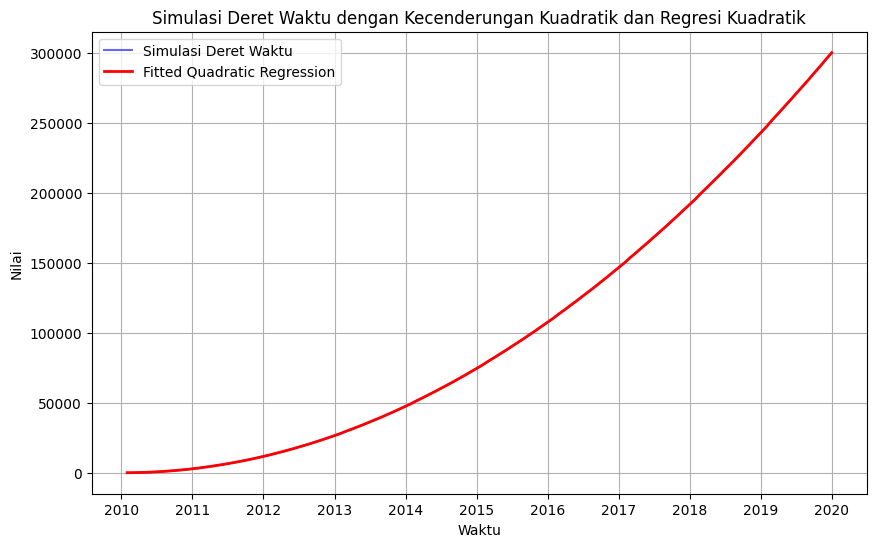

In [ ]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

**Jawab**

Berdasarkan plot, garis hasil regresi kuadratik hampir berimpit dengan data simulasi. Hal ini menunjukkan bahwa nilai prediksi yang dihasilkan oleh model sangat dekat dengan nilai data sebenarnya.

Bentuk garis yang melengkung ke atas juga sesuai dengan pola kecenderungan kuadratik, yaitu nilai deret meningkat semakin cepat seiring bertambahnya waktu. Secara visual, model regresi kuadratik sudah mampu mengikuti pola deret dengan sangat baik.

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

**Jawab**


Berdasarkan hasil pengepasan model dan plot, model regresi kuadratik sudah sesuai untuk menggambarkan pola deret tersebut. Hal ini terlihat dari garis hasil regresi yang hampir berimpit dengan data simulasi, sehingga nilai prediksi model sangat dekat dengan nilai aktual.

Selain itu, hasil regresi sebelumnya menunjukkan nilai $R^2 = 1.000$ dan koefisien $t$ serta $t^2$ memiliki *p-value* < 0.05. Hal ini menunjukkan bahwa model mampu menjelaskan pola kuadratik pada data dengan sangat baik.
Namun, untuk memastikan bahwa model regresi sudah tepat secara keseluruhan, asumsi-asumsi residual tetap perlu diperiksa lebih lanjut.

In [ ]:
# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [ ]:
# Menentukan parameter simulasi
np.random.seed(1021)
n_periods = 120
beta0, beta1, beta2=71, 4, 19
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


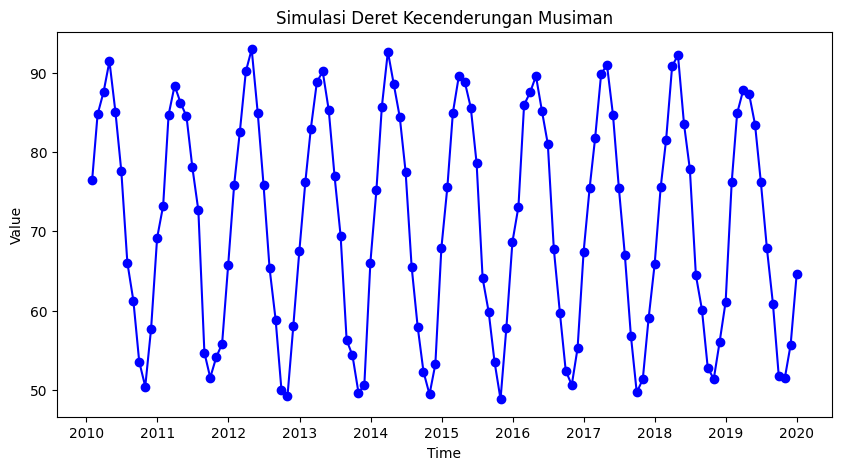

In [ ]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

**Jawab**

Dari plot terlihat bahwa nilai deret bergerak naik dan turun secara berulang dengan pola yang relatif sama. Karena periode musimannya adalah 12, pola tersebut berulang setiap 12 periode.

Hal ini menunjukkan adanya pola musiman yang kuat pada deret. Nilai deret cenderung mencapai titik tinggi pada periode tertentu dan turun pada periode lainnya, kemudian pola tersebut berulang kembali pada siklus berikutnya. Selain itu, tidak terlihat adanya kecenderungan naik atau turun jangka panjang yang jelas, sehingga perubahan pada deret lebih didominasi oleh pola musiman.

In [ ]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [ ]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Interpretasi Variabel Dummy Musiman

Variabel dummy digunakan untuk membedakan masing-masing bulan dalam satu periode musiman. Untuk setiap observasi, hanya satu variabel bulan yang bernilai 1, sedangkan variabel bulan lainnya bernilai 0.

Sebagai contoh, jika suatu observasi berada pada bulan Januari, maka dummy Januari bernilai 1 dan dummy bulan lainnya bernilai 0. Dengan cara ini, pengaruh masing-masing bulan terhadap nilai deret dapat dimasukkan ke dalam model regresi.

In [ ]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [ ]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     594.0
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           3.48e-91
Time:                        07:23:00   Log-Likelihood:                -239.31
No. Observations:                 120   AIC:                             502.6
Df Residuals:                     108   BIC:                             536.1
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       75.2914      0.593    127.061      0.0

Bagaimana interpretasi dari hasil tersebut?

**Jawab**

Berdasarkan hasil regresi musiman, setiap koefisien menunjukkan rata-rata nilai deret pada masing-masing bulan karena model dibuat tanpa intercept. Sebagai contoh, koefisien Januari sebesar 75.2914 menunjukkan bahwa rata-rata nilai deret pada bulan Januari adalah sekitar 75.29. Koefisien Februari sebesar 83.9715 menunjukkan rata-rata bulan Februari sekitar 83.97, dan seterusnya.

Dari nilai koefisien terlihat adanya pola musiman yang jelas. Nilai deret meningkat dari Januari dan mencapai nilai yang relatif tinggi pada Maret-April, kemudian menurun hingga mencapai nilai terendah sekitar September-Oktober, lalu kembali meningkat menuju akhir tahun.

Nilai $R^2 = 0.984$ menunjukkan bahwa sekitar 98.4% variasi nilai deret dapat dijelaskan oleh perbedaan bulan dalam model musiman. Nilai Prob(F-statistic) yang sangat kecil menunjukkan bahwa model secara keseluruhan signifikan.

Seluruh koefisien bulan memiliki *p-value* sebesar 0.000 < 0.05, sehingga masing-masing koefisien bulan signifikan atau berbeda dari nol.

Nilai Durbin-Watson = 2.181 yang mendekati 2 menunjukkan bahwa secara awal tidak terlihat adanya autokorelasi residual yang kuat. Selain itu, nilai Prob(Omnibus) = 0.197 dan Prob(Jarque-Bera) = 0.207 lebih besar dari 0.05, sehingga tidak terdapat bukti yang cukup bahwa residual menyimpang dari distribusi normal.

In [ ]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

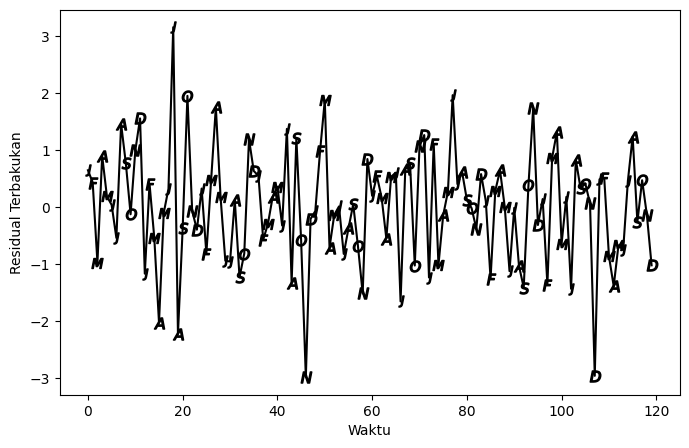

In [ ]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


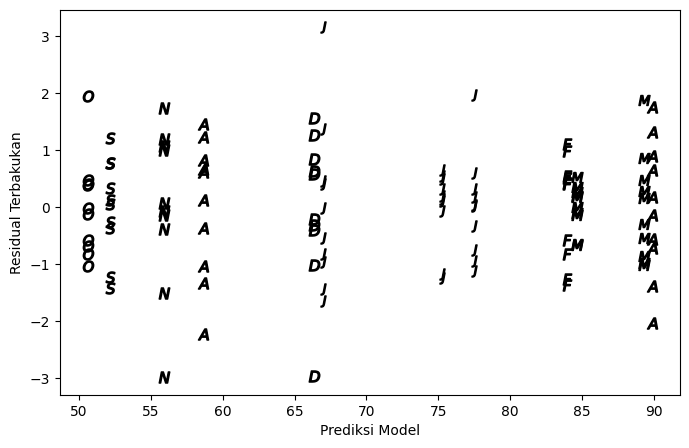

In [ ]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

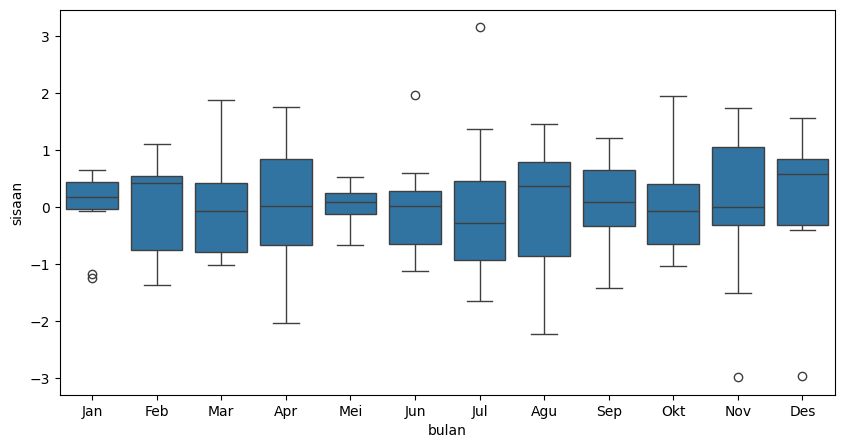

In [ ]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

**Jawab**

Berdasarkan ketiga plot residual, dapat dilihat bahwa:

1. **Residuals vs Time**  
   Residual terlihat menyebar secara acak di sekitar garis nol sepanjang waktu dan tidak menunjukkan pola tren atau pola musiman yang jelas. Hal ini menunjukkan bahwa pola musiman pada data sudah cukup baik ditangkap oleh model.

2. **Residuals vs Predicted Values**  
   Residual tersebar di sekitar garis nol dan tidak menunjukkan pola tertentu. Titik-titik terlihat membentuk beberapa kelompok vertikal karena model musiman menghasilkan nilai prediksi yang berbeda untuk masing-masing bulan. Secara umum, tidak terlihat pola sistematis yang menunjukkan masalah pada residual.

3. **Boxplot Residual berdasarkan Bulan**  
   Residual pada setiap bulan umumnya berpusat di sekitar nol. Sebaran residual antarbulan terlihat relatif serupa, meskipun terdapat beberapa nilai yang cukup ekstrem pada bulan tertentu. Secara umum, tidak terlihat perbedaan pola residual yang mencolok antarbulan.

Dari ketiga plot tersebut, residual secara umum terlihat menyebar secara acak di sekitar nol dan tidak menunjukkan pola sistematis yang kuat. Hal ini menunjukkan bahwa model musiman sudah cukup baik dalam menangkap pola utama pada deret.

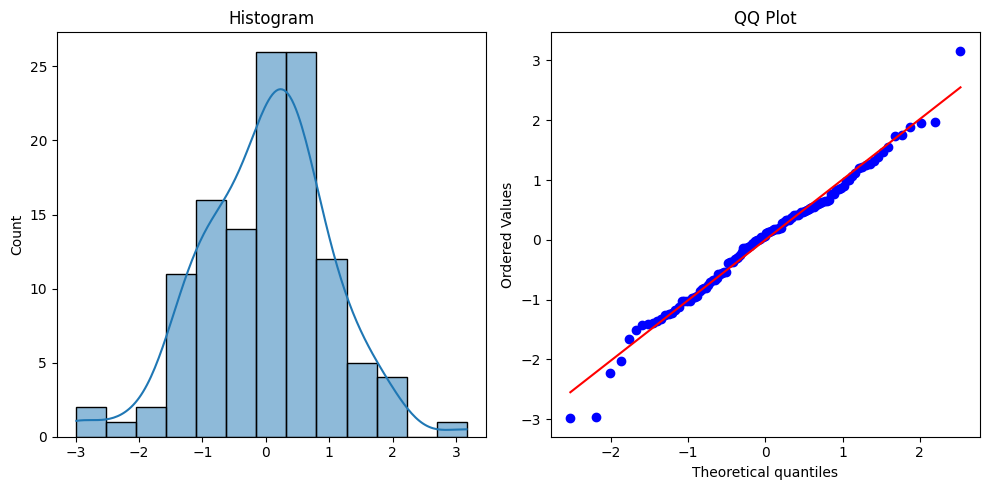

In [ ]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

**Jawab**

Berdasarkan histogram residual terstandarisasi, residual terlihat cukup simetris dan sebagian besar berada di sekitar nilai nol. Bentuk histogram juga secara umum mendekati pola distribusi normal.

Pada QQ Plot, sebagian besar titik mengikuti dan berada di sekitar garis diagonal, meskipun terdapat sedikit penyimpangan pada bagian ekor. Secara visual, hal ini menunjukkan bahwa residual cukup mendekati distribusi normal.

Dengan demikian, dari sisi normalitas residual, model yang dipaskan terhadap data dapat dikatakan cukup sesuai. Namun, untuk menyatakan bahwa model sudah tepat secara keseluruhan, asumsi lainnya juga perlu diperiksa dengan uji statistik.





Hitunglah statistik uji untuk mengecek asumsi model

In [ ]:
# Uji normalitas Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(musiman.resid)
print("Shapiro-Wilk Test")
print("Statistic =", shapiro_stat)
print("p-value =", shapiro_p)

# Uji autokorelasi Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(musiman.resid, lags=[12], return_df=True)
print("\nLjung-Box Test")
print(ljung_box)

# Uji homoskedastisitas Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

# Untuk uji BP gunakan bentuk ekuivalen: intercept + 11 dummy
X_bp = sm.add_constant(musim.iloc[:, 1:])

bp_test = het_breuschpagan(musiman.resid, X_bp)

print("\nBreusch-Pagan Test")
print("LM Statistic =", bp_test[0])
print("LM p-value =", bp_test[1])
print("F Statistic =", bp_test[2])
print("F p-value =", bp_test[3])

Shapiro-Wilk Test
Statistic = 0.9880056316670122
p-value = 0.37400414992834596

Ljung-Box Test
      lb_stat  lb_pvalue
12  15.339936   0.223371

Breusch-Pagan Test
LM Statistic = 12.62098202026345
LM p-value = 0.3188176190468435
F Statistic = 1.1539972941672294
F p-value = 0.32779545077093153


**Jawab**

Berdasarkan uji Shapiro-Wilk diperoleh *p-value* sebesar 0.3740 > 0.05. Dengan demikian, gagal menolak $H_0$, sehingga residual dapat dianggap berdistribusi normal.

Pada uji Ljung-Box lag ke-12 diperoleh *p-value* sebesar 0.2234 > 0.05. Hal ini menunjukkan bahwa tidak terdapat bukti autokorelasi residual hingga lag ke-12.

Sementara itu, pada uji Breusch-Pagan diperoleh LM *p-value* sebesar 0.3188 dan F *p-value* sebesar 0.3278, yang keduanya lebih besar dari 0.05. Oleh karena itu, tidak terdapat bukti adanya heteroskedastisitas, sehingga asumsi homoskedastisitas dapat dianggap terpenuhi.

Secara keseluruhan, hasil pengujian menunjukkan bahwa residual memenuhi asumsi normalitas, tidak menunjukkan autokorelasi yang signifikan, dan memiliki varians yang relatif konstan. Dengan demikian, asumsi utama model regresi musiman tanpa intersep dapat dianggap terpenuhi.

In [ ]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [ ]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [ ]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     594.0
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           3.48e-91
Time:                        07:23:05   Log-Likelihood:                -239.31
No. Observations:                 120   AIC:                             502.6
Df Residuals:                     108   BIC:                             536.1
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.2914      0.593    127.061      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

**Jawab**

Model regresi musiman dengan intersep dan tanpa intersep pada dasarnya menggambarkan pola musiman yang sama, tetapi cara menginterpretasikan koefisiennya berbeda.

Pada model tanpa intersep, setiap koefisien bulan langsung menunjukkan rata-rata nilai deret pada bulan tersebut. Sebagai contoh, koefisien Januari sebesar 75.2914 berarti rata-rata nilai deret pada bulan Januari sekitar 75.29.

Pada model dengan intersep, Januari digunakan sebagai kategori acuan. Nilai konstanta sebesar 75.2914 menunjukkan rata-rata nilai deret pada bulan Januari, sedangkan koefisien bulan Februari sampai Desember menunjukkan selisih rata-rata masing-masing bulan terhadap Januari.

Sebagai contoh, koefisien Februari sebesar 8.6801 berarti rata-rata nilai deret pada bulan Februari sekitar 8.68 satuan lebih tinggi dibandingkan Januari. Dengan demikian, perkiraan rata-rata Februari adalah:

$$
75.2914 + 8.6801 = 83.9715
$$

Sementara itu, koefisien September sebesar -23.1556 berarti rata-rata nilai deret pada bulan September sekitar 23.16 satuan lebih rendah dibandingkan Januari.

Nilai $R^2$ pada model dengan intersep sebesar 0.984, sama dengan model tanpa intersep. Hal ini menunjukkan bahwa kedua parameterisasi model mampu menjelaskan pola musiman pada data dengan kemampuan yang sama. Perbedaannya terutama terletak pada cara penulisan dan interpretasi koefisien.

Untuk menentukan apakah model dengan intersep sudah memenuhi asumsi regresi, perlu dilakukan pemeriksaan terhadap residual model tersebut. Oleh karena itu, belum dapat disimpulkan hanya berdasarkan tabel hasil regresi bahwa seluruh asumsi model dengan intersep sudah terpenuhi.

In [ ]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [ ]:
# Parameter
np.random.seed(1021)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 21.5, 31 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


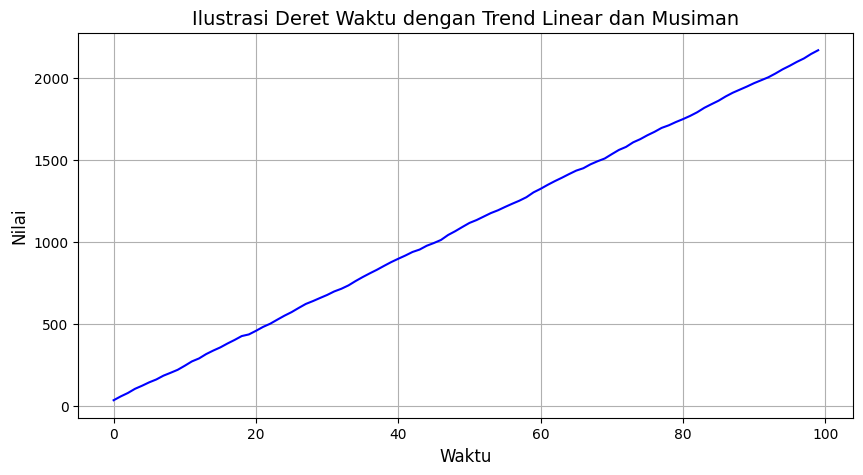

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

### Interpretasi Plot

Berdasarkan plot, deret waktu menunjukkan kecenderungan meningkat secara linear dari waktu ke waktu. Hal ini terlihat dari nilai deret yang terus meningkat seiring bertambahnya periode.

Selain tren linear, terdapat pola naik-turun yang berulang pada deret yang menunjukkan adanya komponen musiman. Namun, pengaruh musiman terlihat relatif kecil dibandingkan dengan kenaikan akibat tren, sehingga pola deret secara keseluruhan lebih didominasi oleh kecenderungan linear.

Dengan demikian, deret waktu tersebut memiliki dua komponen utama, yaitu tren linear yang meningkat dan pola musiman yang berulang secara periodik.

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [ ]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [ ]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [ ]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.108e+05
Date:                Thu, 03 Sep 2026   Prob (F-statistic):          2.79e-216
Time:                        07:23:05   Log-Likelihood:                -197.88
No. Observations:                 100   AIC:                             421.8
Df Residuals:                      87   BIC:                             455.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       31.3010      0.699     44.753      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

**Jawab**


Pada model regresi ini, nilai konstanta (*const*) menunjukkan nilai dasar deret pada bulan Januari ketika variabel periode bernilai 0. Koefisien periode menunjukkan perubahan rata-rata nilai deret setiap terjadi penambahan satu periode waktu, dengan pengaruh musiman dianggap tetap.

Koefisien periode bernilai positif, sehingga menunjukkan bahwa deret memiliki tren yang meningkat dari waktu ke waktu. Artinya, setiap bertambah satu periode, nilai deret diperkirakan mengalami peningkatan sebesar nilai koefisien periode.

Sementara itu, koefisien dummy bulan menunjukkan perbedaan rata-rata nilai deret pada bulan tersebut dibandingkan dengan Januari sebagai bulan acuan, setelah pengaruh tren waktu diperhitungkan. Koefisien yang bernilai positif berarti nilai pada bulan tersebut lebih tinggi dibandingkan Januari, sedangkan koefisien negatif berarti lebih rendah dibandingkan Januari.

Dengan demikian, hasil regresi menunjukkan bahwa nilai deret dipengaruhi oleh dua komponen, yaitu kecenderungan linear yang meningkat dari waktu ke waktu dan pengaruh musiman yang menyebabkan adanya perbedaan nilai antarbulan.

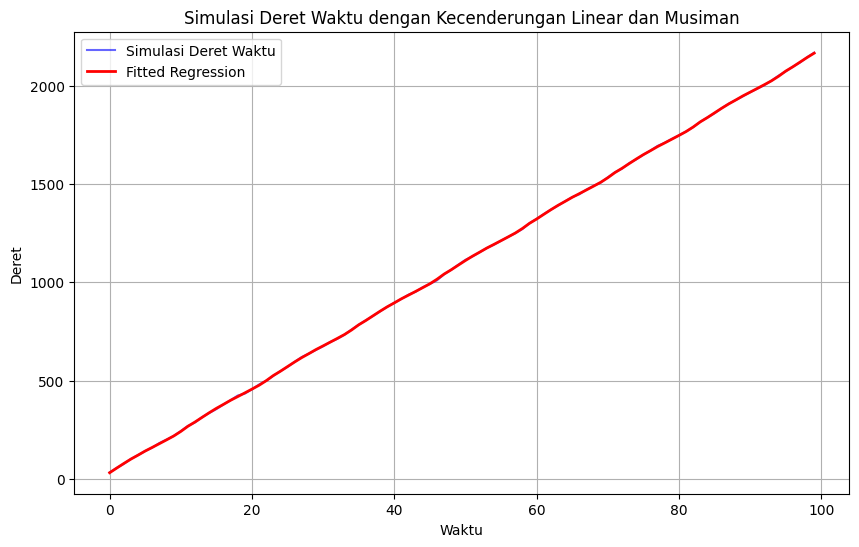

In [ ]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

### Interpretasi Plot

Berdasarkan plot, garis hasil regresi terlihat hampir berimpit dengan data simulasi sepanjang periode pengamatan. Hal ini menunjukkan bahwa nilai prediksi yang dihasilkan model sangat dekat dengan nilai data sebenarnya.

Model mampu mengikuti kecenderungan nilai deret yang meningkat dari waktu ke waktu sekaligus menangkap perubahan yang disebabkan oleh pola musiman. Dengan demikian, secara visual model regresi linear dengan komponen musiman sudah mampu menggambarkan pola deret dengan sangat baik.

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [ ]:
# uji asumsi model

from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

# Residual model
resid_mix = model_mix.resid

# 1. Uji Normalitas Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(resid_mix)
print("Shapiro-Wilk Test")
print("Statistic =", shapiro_stat)
print("p-value =", shapiro_p)

# 2. Uji Autokorelasi Ljung-Box
ljung_box = acorr_ljungbox(resid_mix, lags=[12], return_df=True)
print("\nLjung-Box Test")
print(ljung_box)

# 3. Uji Homoskedastisitas Breusch-Pagan
# Bentuk ekuivalen: konstanta + 11 dummy bulan + period
X_bp = sm.add_constant(season.drop(columns=["Januari"]))

bp_test = het_breuschpagan(resid_mix, X_bp)

print("\nBreusch-Pagan Test")
print("LM Statistic =", bp_test[0])
print("LM p-value =", bp_test[1])
print("F Statistic =", bp_test[2])
print("F p-value =", bp_test[3])

Shapiro-Wilk Test
Statistic = 0.99210795398616
p-value = 0.8289909807539146

Ljung-Box Test
      lb_stat  lb_pvalue
12  16.262095   0.179524

Breusch-Pagan Test
LM Statistic = 16.606904993367667
LM p-value = 0.16499198864706938
F Statistic = 1.443765352423244
F p-value = 0.16194116472571043


**Jawab***

Berdasarkan hasil pengujian asumsi model, diperoleh hasil sebagai berikut:

1. **Uji Normalitas Shapiro-Wilk**

   Diperoleh nilai statistik Shapiro-Wilk sebesar **0.9921** dengan *p-value* sebesar **0.8290 > 0.05**. Dengan demikian, gagal menolak $H_0$, sehingga residual dapat dianggap berdistribusi normal.

2. **Uji Autokorelasi Ljung-Box**

   Pada lag ke-12 diperoleh nilai statistik Ljung-Box sebesar **16.2621** dengan *p-value* sebesar **0.1795 > 0.05**. Dengan demikian, gagal menolak $H_0$, sehingga tidak terdapat bukti adanya autokorelasi residual hingga lag ke-12.

3. **Uji Homoskedastisitas Breusch-Pagan**

   Diperoleh LM Statistic sebesar **16.6069** dengan *p-value* sebesar **0.1650 > 0.05**. Selain itu, F Statistic sebesar **1.4438** dengan *p-value* sebesar **0.1619 > 0.05**. Dengan demikian, tidak terdapat bukti adanya heteroskedastisitas, sehingga varians residual dapat dianggap konstan.

Secara keseluruhan, hasil pengujian tidak menunjukkan adanya pelanggaran yang signifikan terhadap asumsi normalitas, independensi residual, dan homoskedastisitas. Dengan demikian, asumsi utama model regresi linear dan musiman yang diperiksa dapat dianggap terpenuhi.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [ ]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

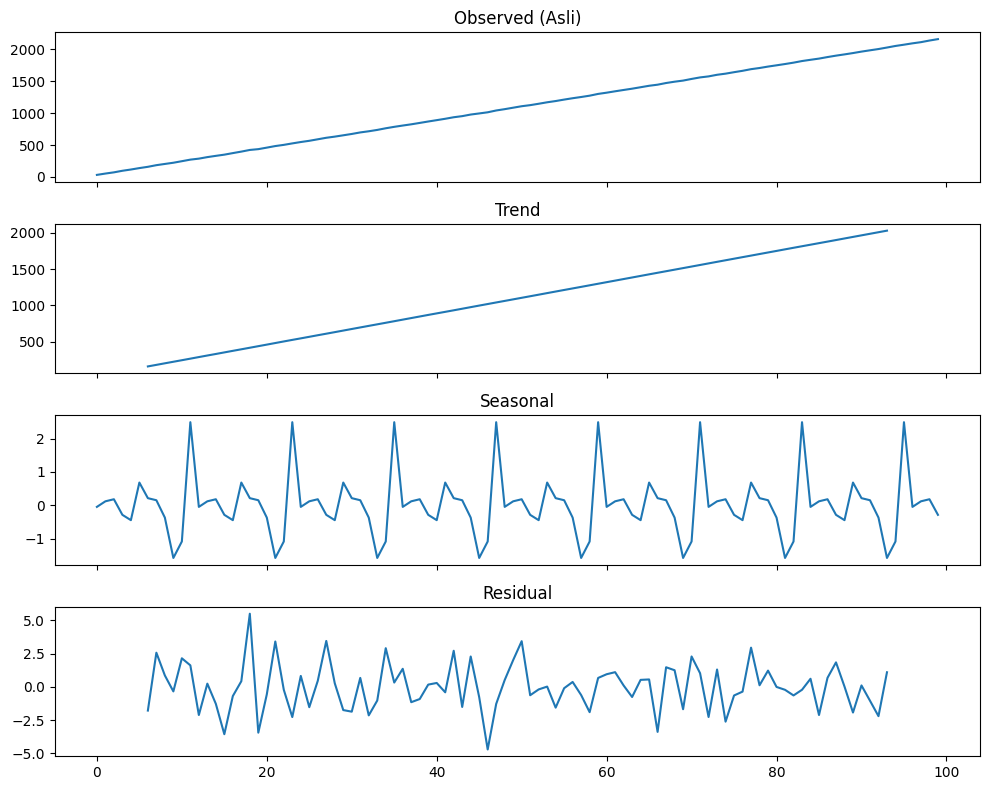

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

**Jawab**

Berdasarkan hasil dekomposisi aditif, deret waktu dapat diuraikan menjadi komponen tren, musiman, dan residual.

1. **Observed (Asli)**  
   Deret asli menunjukkan nilai yang cenderung meningkat dari waktu ke waktu. Selain itu, terdapat perubahan naik-turun di sekitar kecenderungan tersebut.

2. **Trend**  
   Komponen tren menunjukkan pola yang meningkat secara hampir linear. Hal ini menunjukkan bahwa deret memiliki kecenderungan jangka panjang yang terus meningkat seiring bertambahnya waktu.

3. **Seasonal**  
   Komponen musiman menunjukkan pola naik-turun yang berulang secara teratur dengan periode 12. Hal ini menunjukkan adanya pola musiman yang berulang setiap 12 periode.

4. **Residual**  
   Komponen residual merupakan variasi yang tersisa setelah komponen tren dan musiman dipisahkan dari deret. Residual terlihat berfluktuasi di sekitar nol dan tidak menunjukkan pola sistematis yang jelas.

Secara keseluruhan, hasil dekomposisi menunjukkan bahwa deret terdiri atas tren linear yang meningkat, pola musiman yang berulang setiap 12 periode, serta komponen residual atau noise.

In [ ]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

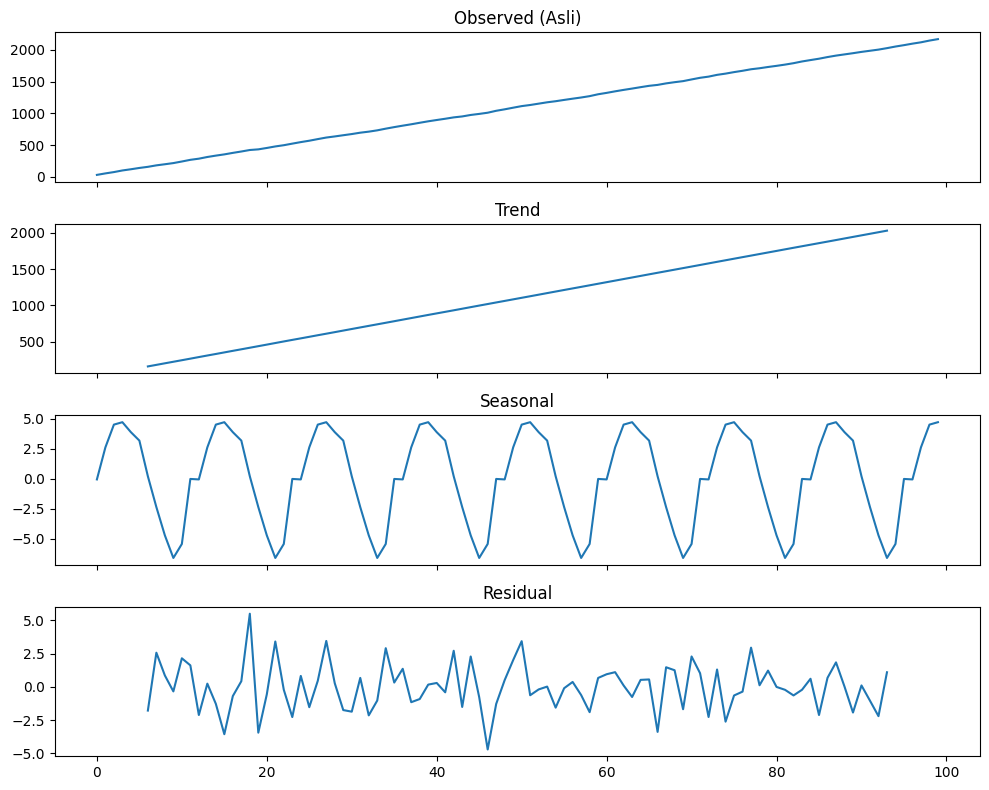

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

**Jawab**

Berdasarkan hasil dekomposisi, deret dapat dipisahkan menjadi komponen tren, musiman, dan residual.

1. **Observed (Asli)**  
   Deret asli menunjukkan kecenderungan meningkat dari waktu ke waktu dengan pola naik-turun yang berulang. Pola musiman pada deret ini terlihat lebih jelas dibandingkan dengan simulasi sebelumnya.

2. **Trend**  
   Komponen tren menunjukkan pola yang meningkat secara linear. Hal ini menunjukkan adanya kecenderungan jangka panjang berupa peningkatan nilai deret seiring bertambahnya waktu.

3. **Seasonal**  
   Komponen musiman menunjukkan pola naik-turun yang berulang secara teratur setiap 12 periode. Dibandingkan dengan dekomposisi sebelumnya, pola musiman terlihat lebih jelas karena amplitudo komponen musimannya lebih besar.

4. **Residual**  
   Komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu yang jelas. Residual ini menggambarkan variasi acak yang tidak dapat dijelaskan oleh komponen tren maupun musiman.

Secara keseluruhan, hasil dekomposisi berhasil memisahkan deret menjadi tren linear yang meningkat, pola musiman yang berulang setiap 12 periode, dan residual yang bersifat acak.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [ ]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1021)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 21.05, 31 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

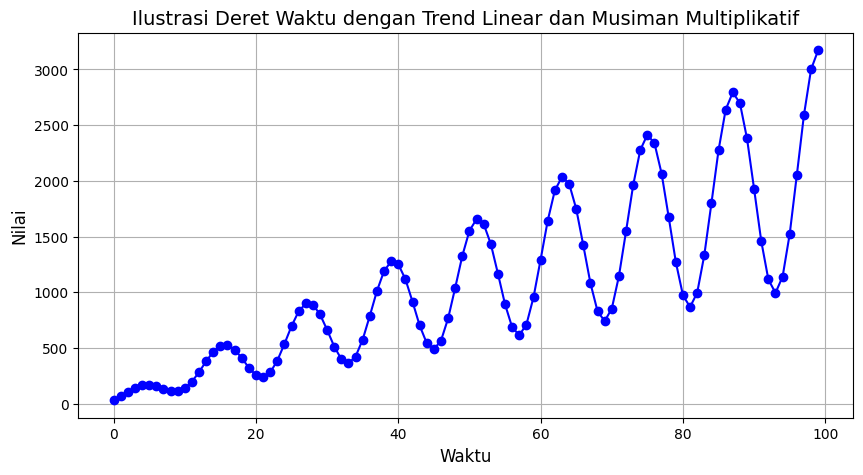

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

### Interpretasi Plot

Berdasarkan plot, deret waktu menunjukkan kecenderungan meningkat dari waktu ke waktu dan memiliki pola musiman yang berulang secara teratur.

Besarnya fluktuasi musiman juga terlihat semakin meningkat seiring dengan meningkatnya level deret. Pada awal periode, jarak antara nilai tertinggi dan terendah relatif kecil, sedangkan pada periode berikutnya jarak tersebut semakin besar.

Pola tersebut menunjukkan karakteristik musiman multiplikatif, yaitu pengaruh musiman berubah mengikuti besarnya level deret. Semakin tinggi nilai deret, semakin besar pula fluktuasi musimannya.

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [ ]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

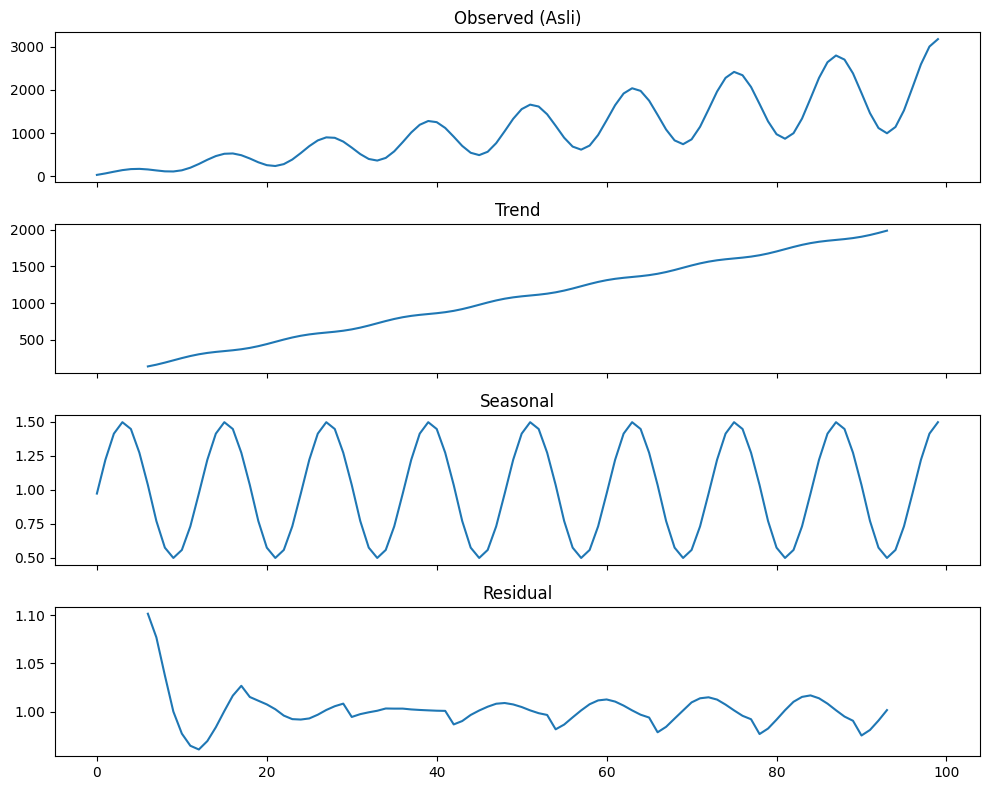

In [ ]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

**Jawab**

Berdasarkan hasil dekomposisi multiplikatif, deret waktu dapat dipisahkan menjadi komponen tren, musiman, dan residual.

1. **Observed (Asli)**  
   Deret asli menunjukkan kecenderungan meningkat dari waktu ke waktu dengan pola naik-turun yang berulang. Besarnya fluktuasi musiman juga semakin meningkat ketika level deret semakin tinggi.

2. **Trend**  
   Komponen tren menunjukkan kecenderungan meningkat secara linear. Hal ini menunjukkan bahwa dalam jangka panjang nilai deret terus mengalami peningkatan seiring bertambahnya waktu.

3. **Seasonal**  
   Komponen musiman menunjukkan pola yang berulang secara teratur setiap 12 periode. Pada model multiplikatif, komponen musiman bekerja secara proporsional terhadap level deret, sehingga besarnya fluktuasi pada data asli meningkat ketika level deret meningkat.

4. **Residual**  
   Komponen residual menunjukkan variasi yang tersisa setelah pengaruh tren dan musiman dipisahkan dari deret. Residual diharapkan berfluktuasi di sekitar nilai 1 pada model multiplikatif dan tidak menunjukkan pola sistematis yang jelas.

Secara keseluruhan, dekomposisi multiplikatif sesuai untuk deret tersebut karena besarnya fluktuasi musiman berubah mengikuti level deret. Semakin tinggi level deret, semakin besar pula variasi musimannya.

In [ ]:
# Parameter
np.random.seed(1021)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

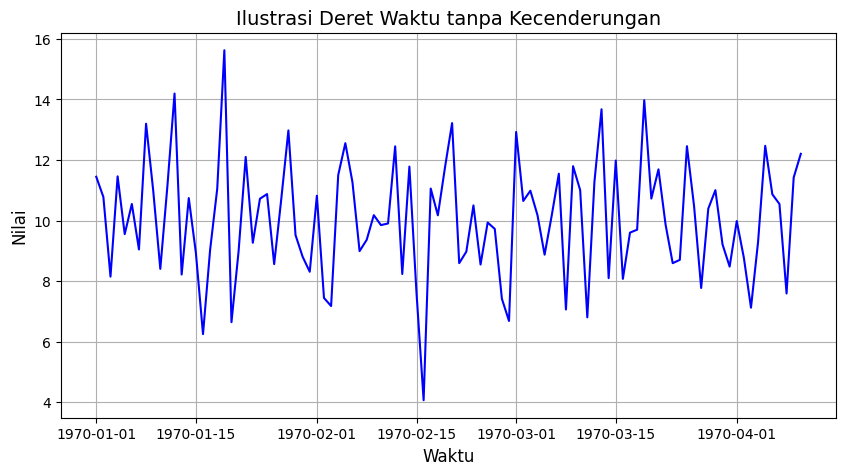

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

### Interpretasi Plot


Berdasarkan plot, nilai deret berfluktuasi naik dan turun di sekitar tingkat rata-rata yang relatif konstan. Tidak terlihat adanya pola kenaikan atau penurunan yang berlangsung secara terus-menerus seiring bertambahnya waktu.

Fluktuasi yang terjadi juga tidak membentuk pola tertentu yang jelas. Dengan demikian, deret tersebut dapat dikatakan tidak memiliki kecenderungan atau tren yang jelas dan lebih menunjukkan variasi acak di sekitar rata-ratanya.

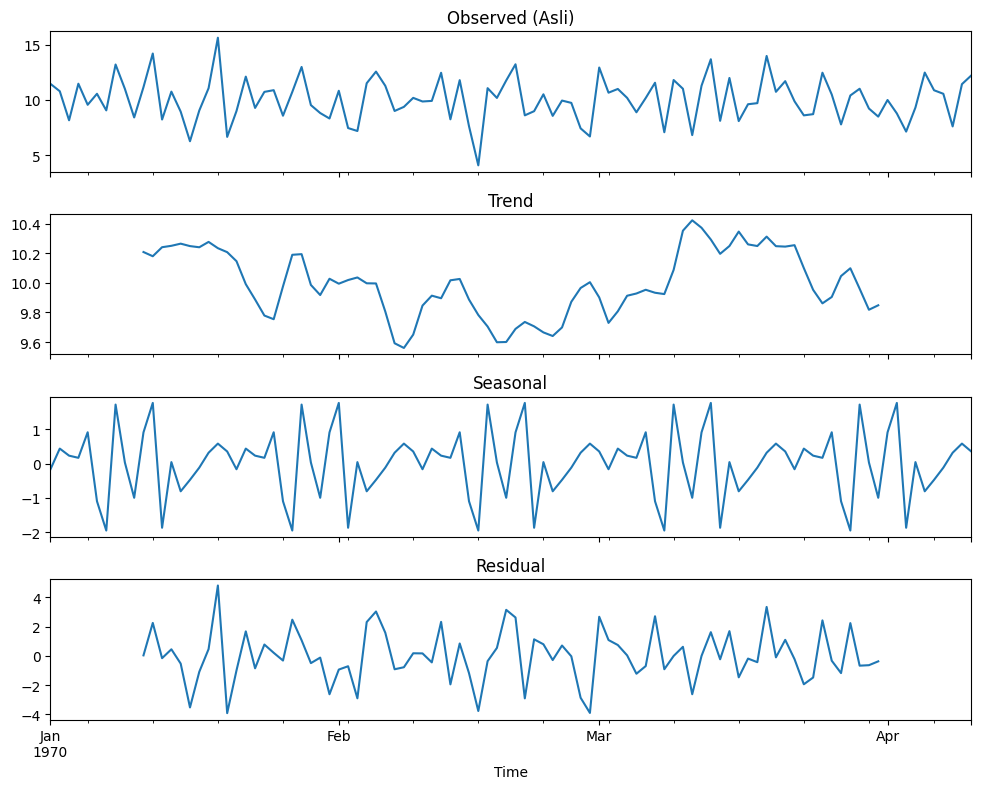

In [ ]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

**Jawab**

Berdasarkan hasil dekomposisi, dapat dilihat bahwa:

1. **Observed (Asli)**  
   Deret asli berfluktuasi naik dan turun di sekitar nilai yang relatif konstan. Tidak terlihat adanya kecenderungan meningkat atau menurun secara terus-menerus sepanjang waktu.

2. **Trend**  
   Komponen tren berada pada kisaran nilai yang relatif stabil, yaitu sekitar 10. Meskipun terdapat sedikit kenaikan dan penurunan, tidak terlihat adanya kecenderungan jangka panjang yang kuat. Hal ini sesuai dengan karakteristik data yang dibangkitkan tanpa kecenderungan.

3. **Seasonal**  
   Komponen musiman menunjukkan fluktuasi di sekitar nol. Namun, pola yang terbentuk tidak menunjukkan pola musiman yang kuat dan konsisten. Oleh karena itu, deret tidak menunjukkan adanya komponen musiman yang jelas.

4. **Residual**  
   Residual berfluktuasi secara acak di sekitar nol dengan nilai positif dan negatif serta tidak menunjukkan pola tertentu yang jelas. Hal ini menunjukkan bahwa sebagian besar variasi yang tersisa bersifat acak.

Secara keseluruhan, hasil dekomposisi menunjukkan bahwa deret tidak memiliki tren maupun pola musiman yang kuat. Pergerakan deret lebih banyak didominasi oleh fluktuasi acak atau noise di sekitar tingkat rata-rata yang relatif konstan.